#**Customer management in CRM**

### **Problem:**

The Customer Care and Marketing departments of an e-commerce platform are preparing for a year-end appreciation campaign. However, the gift budget is limited. The Marketing Director has requested:

“Please segment our customer base into three groups—A, B, and C—based on the total profit they generate. I want to allocate 80% of the VIP gift budget to the most valuable customer group and identify who they are (their income levels, occupations, etc.).”

### **Task:**

**Analyze and answer the following questions:**

What percentage of the total customer base does Group A represent? (Does it follow the Pareto principle?)
If the company only has 500 special gift slots, does the number of Group A customers exceed this limit?
Based on customers’ income and occupation data, what recommendations would you propose for the upcoming marketing campaign to attract more new “Group A” customers?

###**Import the Library**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

###**Import Data**

In [ ]:
path_1 = '/content/Customer.csv'
path_2 = '/content/EcomSales.csv'
path_3 = '/content/Product.csv'
path_4 = '/content/Region.csv'

In [ ]:
customer_df = pd.read_csv(path_1)
ecom_sales_df = pd.read_csv(path_2)
product_df = pd.read_csv(path_3)
region_df = pd.read_csv(path_4)

In [ ]:
customer_df.head(5)

,CustomerID,FirstName,LastName,BirthDate,MaritalStatus,Gender,EmailAddress,AnnualIncome,EducationLevel,Occupation,HomeOwner
0,TH-211151,Jon,Huang,6/18/1962,M,M,jon24@hotmail.com,90000,Bachelors,Professional,Y
1,BD-116051,Eugene,Torres,6/16/1985,S,M,eugene10@hotmail.com,60000,Bachelors,Professional,N
2,TS-212051,Ruben,Zhu,6/28/1985,M,M,ruben35@hotmail.com,60000,Bachelors,Professional,Y
3,SU-206651,Christy,Johnson,8/4/1988,S,F,christy12@hotmail.com,70000,Bachelors,Professional,N
4,GM-144551,Elizabeth,Ruiz,1/12/1960,S,F,elizabeth5@hotmail.com,80000,Bachelors,Professional,Y


In [ ]:
ecom_sales_df.head(5)

,RowID,OrderID,OrderDate,CustomerID,Segment,RegionCode,ProductCode,Quantity,Sales,Discount,Profit
0,25221,IN-2012-TH211151-41003,4/4/2020,TH-211151,Corporate,RRR0001,P000001,13,416,0.0,208.0
1,29464,ID-2013-BD116051-41518,9/1/2021,BD-116051,Consumer,R0002,PPP000002,4,20,0.0,10.0
2,27311,IN-2015-TS212051-42173,6/18/2023,TS-212051,Corporate,R0003,P000003,2,20,0.0,8.0
3,28882,IN-2014-SU206651-41899,9/17/2022,SU-206651,Self-Employed,R0003,P000004,4,556,0.0,55.6
4,27992,IN-2015-GM144551-42217,8/1/2023,GM-144551,Self-Employed,R0003,P000005,2,6,0.0,0.6


In [ ]:
product_df.head(5)

,ProductCode,Product,Category,Subcategory
0,P000001,Soap & Glory Endless Glove Moisturizing Hand C...,Body care,"bath oils, bubbles and soaks"
1,P000002,Pantene Pro-V Truly Relaxed Hair Lightweight C...,Body care,"bath oils, bubbles and soaks"
2,P000003,Estée Lauder Pure Color Envy Irresistible,Body care,"bath oils, bubbles and soaks"
3,P000004,Gold Infinity Bracelet,Body care,body moisturizers
4,P000005,Deborah Lippmann Nail Polish Lady is a Tramp C...,Body care,body moisturizers


In [ ]:
region_df.head(5)

,RegionCode,City,State,Country,Countrylatitude,Countrylongitude,Region,Market
0,R0001,Jalalabad,Nangarhar,Afghanistan,33.939110,67.709953,Southern Asia,Asia Pacific
1,R0002,Herat,Hirat,Afghanistan,33.939110,67.709953,Southern Asia,Asia Pacific
2,R0003,Kabul,Kabul,Afghanistan,33.939110,67.709953,Southern Asia,Asia Pacific
3,R0004,Kandahar,Kandahar,Afghanistan,33.939110,67.709953,Southern Asia,Asia Pacific
4,R0005,Elbasan,Elbasan,Albania,41.153332,20.168331,Southern Europe,Europe


###**Data Information**

In [ ]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17415 entries, 0 to 17414
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   CustomerID      17415 non-null  object
 1   FirstName       17415 non-null  object
 2   LastName        17415 non-null  object
 3   BirthDate       17415 non-null  object
 4   MaritalStatus   17415 non-null  object
 5   Gender          17291 non-null  object
 6   EmailAddress    17415 non-null  object
 7   AnnualIncome    17415 non-null  int64 
 8   EducationLevel  17415 non-null  object
 9   Occupation      17415 non-null  object
 10  HomeOwner       17415 non-null  object
dtypes: int64(1), object(10)
memory usage: 1.5+ MB


In [ ]:
ecom_sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   RowID        51290 non-null  int64  
 1   OrderID      51290 non-null  object 
 2   OrderDate    51290 non-null  object 
 3   CustomerID   51290 non-null  object 
 4   Segment      51290 non-null  object 
 5   RegionCode   51290 non-null  object 
 6   ProductCode  51290 non-null  object 
 7   Quantity     51290 non-null  int64  
 8   Sales        51290 non-null  int64  
 9   Discount     51290 non-null  float64
 10  Profit       51290 non-null  float64
dtypes: float64(2), int64(3), object(6)
memory usage: 4.3+ MB


In [ ]:
product_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28356 entries, 0 to 28355
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ProductCode  28356 non-null  object
 1   Product      28356 non-null  object
 2   Category     28356 non-null  object
 3   Subcategory  28356 non-null  object
dtypes: object(4)
memory usage: 886.3+ KB


In [ ]:
region_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3828 entries, 0 to 3827
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   RegionCode        3828 non-null   object 
 1   City              3828 non-null   object 
 2   State             3828 non-null   object 
 3   Country           3828 non-null   object 
 4   Countrylatitude   3828 non-null   float64
 5   Countrylongitude  3828 non-null   float64
 6   Region            3828 non-null   object 
 7   Market            3828 non-null   object 
dtypes: float64(2), object(6)
memory usage: 239.4+ KB


### **Handling Missing Data and Duplicated Data**

In [ ]:
customer_df.isnull().sum()

,0
CustomerID,0
FirstName,0
LastName,0
BirthDate,0
MaritalStatus,0
Gender,124
EmailAddress,0
AnnualIncome,0
EducationLevel,0
Occupation,0


Regarding the CRM Customer Management assignment, for the missing values in the Gender column, I believe they are not particularly important since this task focuses on customer segmentation for gift allocation. Therefore, I will not handle the missing values in this column and will keep them as they are.

In [ ]:
customer_df.duplicated().sum()

np.int64(0)

The customer_df table does not contain any duplicated values.

In [ ]:
ecom_sales_df.isnull().sum()

,0
RowID,0
OrderID,0
OrderDate,0
CustomerID,0
Segment,0
RegionCode,0
ProductCode,0
Quantity,0
Sales,0
Discount,0


In [ ]:
ecom_sales_df.shape

(51290, 11)

As per the problem statement, I'll drop the one row with missing values in the `ecom_sales_df` DataFrame. Since it is a very small portion of the data, dropping it will not significantly impact the analysis.

In [ ]:
ecom_sales_df.dropna(inplace=True)
ecom_sales_df.shape
ecom_sales_df.isnull().sum()

,0
RowID,0
OrderID,0
OrderDate,0
CustomerID,0
Segment,0
RegionCode,0
ProductCode,0
Quantity,0
Sales,0
Discount,0


In [ ]:
product_df.isnull().sum()

,0
ProductCode,0
Product,0
Category,0
Subcategory,0


The product_df table does not contain any missing values.

In [ ]:
product_df.duplicated().sum()

np.int64(0)

The product_df table does not contain any duplicated values.

In [ ]:
region_df.isnull().sum()

,0
RegionCode,0
City,0
State,0
Country,0
Countrylatitude,0
Countrylongitude,0
Region,0
Market,0


The region_df table does not contain any missing values.

In [ ]:
region_df.duplicated().sum()

np.int64(0)

The region_df table does not contain any duplicated values.

### **Handling Outlier Value**

In [ ]:
customer_df.describe().T

,count,mean,std,min,25%,50%,75%,max
AnnualIncome,17415.0,57190.927361,32213.237506,10000.0,30000.0,60000.0,70000.0,170000.0


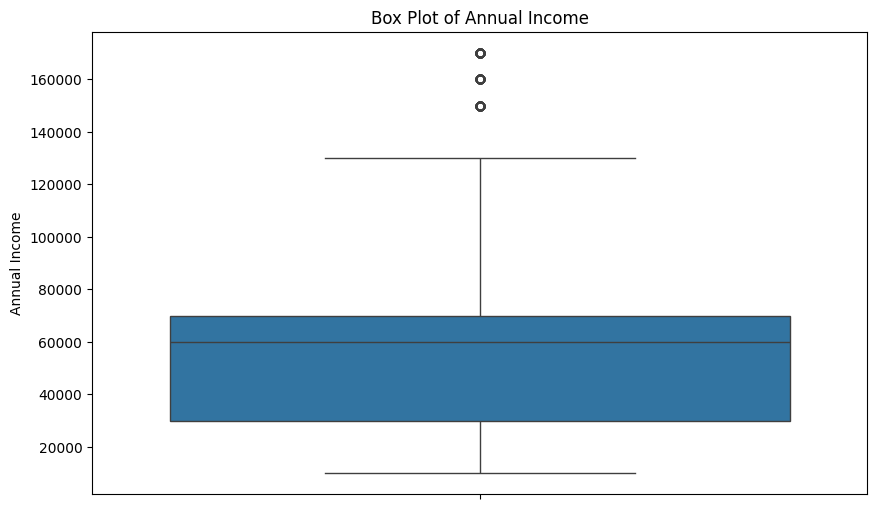

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=customer_df['AnnualIncome'])
plt.title('Box Plot of Annual Income')
plt.ylabel('Annual Income')
plt.show()

The box plot shows the distribution of Annual Income. We can observe some data points that are significantly higher than the rest, indicating potential outliers. We will consider these when forming customer segments.

In [ ]:
ecom_sales_df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowID,51290.0,25645.500000,14806.291990,1.0,12823.25,25645.5,38467.75,51290.00
Quantity,51290.0,5.415832,4.908234,1.0,2.00,4.0,7.00,20.00
Sales,51290.0,127.074946,236.074764,2.0,25.00,56.0,132.00,3940.00
Discount,51290.0,0.142908,0.212280,0.0,0.00,0.0,0.20,0.85
Profit,51290.0,20.772346,83.582680,-1746.0,0.00,7.2,25.00,1820.00


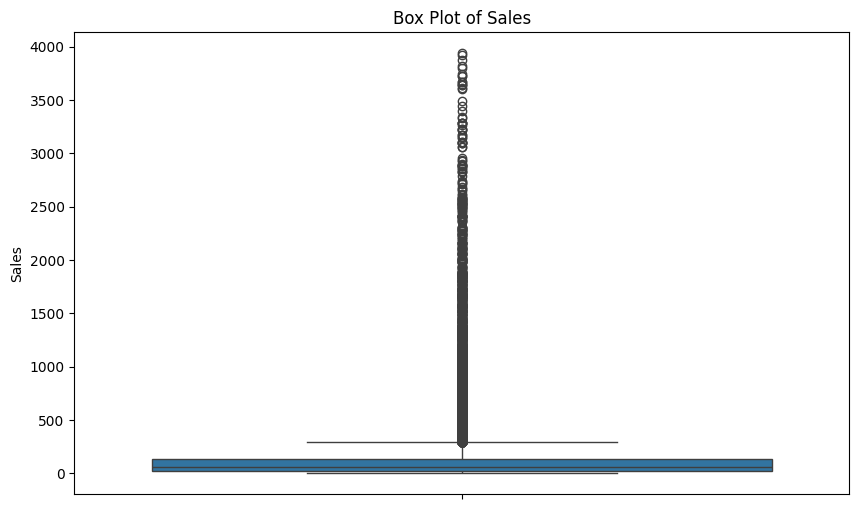

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=ecom_sales_df['Sales'])
plt.title('Box Plot of Sales')
plt.ylabel('Sales')
plt.show()

The box plot above shows the distribution of sales values. We can observe a significant number of data points that are much higher than the majority, indicating potential outliers. This suggests that some transactions involve exceptionally high sales amounts.

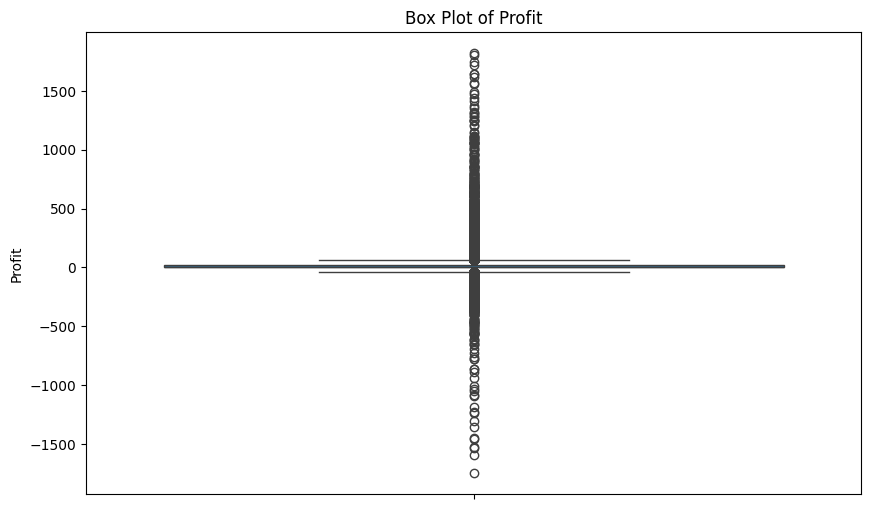

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=ecom_sales_df['Profit'])
plt.title('Box Plot of Profit')
plt.ylabel('Profit')
plt.show()

This box plot illustrates the distribution of profit values. Similar to sales, there are clear outliers, both on the positive and negative ends. Some transactions result in very high profits, while others incur substantial losses. These outliers are crucial to consider when segmenting customers based on profitability.

### **Key Finding:**

Regarding the distribution of 'Sales' and 'Profit' values, the box plots clearly show the presence of outliers. For 'Sales', there are transactions with significantly high values, and for 'Profit', there are both very high positive values and notable negative values (losses). For the purpose of this analysis—segmenting customers based on the total profit they generate—I recommend not removing these outliers. These extreme values, whether very high sales or significant profits/losses, are integral to defining customer value and are exactly what differentiates 'Group A' (most valuable) customers from others. Including them will provide a more accurate and complete picture for your customer segmentation and subsequent marketing strategy.

### **EDA**

##### **Total Profit by Customer**

In [29]:
total_profit_per_customer = ecom_sales_df.groupby('CustomerID')['Profit'].sum().reset_index()
total_profit_per_customer = total_profit_per_customer.rename(columns={'Profit': 'TotalProfit'})
display(total_profit_per_customer.head())

,CustomerID,TotalProfit
0,AA-10315102,-163.70
1,AA-10315120,31.50
2,AA-10315139,135.25
3,AA-103151402,10.70
4,AA-103151404,39.50


In [30]:
customer_sales_df = pd.merge(customer_df, total_profit_per_customer, on='CustomerID', how='left')
display(customer_sales_df.head())

,CustomerID,FirstName,LastName,BirthDate,MaritalStatus,Gender,EmailAddress,AnnualIncome,EducationLevel,Occupation,HomeOwner,TotalProfit
0,TH-211151,Jon,Huang,6/18/1962,M,M,jon24@hotmail.com,90000,Bachelors,Professional,Y,381.2
1,BD-116051,Eugene,Torres,6/16/1985,S,M,eugene10@hotmail.com,60000,Bachelors,Professional,N,46.9
2,TS-212051,Ruben,Zhu,6/28/1985,M,M,ruben35@hotmail.com,60000,Bachelors,Professional,Y,171.2
3,SU-206651,Christy,Johnson,8/4/1988,S,F,christy12@hotmail.com,70000,Bachelors,Professional,N,58.4
4,GM-144551,Elizabeth,Ruiz,1/12/1960,S,F,elizabeth5@hotmail.com,80000,Bachelors,Professional,Y,56.6


In [31]:
customers_sorted_by_profit = customer_sales_df.sort_values(by='TotalProfit', ascending=False).reset_index(drop=True)
display(customers_sorted_by_profit.head())

,CustomerID,FirstName,LastName,BirthDate,MaritalStatus,Gender,EmailAddress,AnnualIncome,EducationLevel,Occupation,HomeOwner,TotalProfit
0,AR-1082564,Joanna,Sun,7/26/1988,M,F,joanna2@hotmail.com,40000,Bachelors,Skilled Manual,Y,2625.3
1,LS-172001402,Katelyn,Gutierrez,6/28/1976,S,F,katelyn0@hotmail.com,70000,Bachelors,Skilled Manual,Y,2429.4
2,MY-1829527,Mitchell,Jimenez,1/27/1983,M,M,mitchell10@hotmail.com,30000,Bachelors,Clerical,Y,2165.0
3,ML-73952,Bethany,Ramos,1/22/1978,M,F,bethany10@hotmail.com,10000,Partial High School,Clerical,Y,2156.0
4,YS-2188093,Billy,Navarro,10/2/1983,M,M,billy21@hotmail.com,90000,High School,Professional,Y,2095.9


In [38]:
# Calculate the total overall profit from all customers
total_overall_profit = customers_sorted_by_profit['TotalProfit'].sum()

# Calculate Cumulative Profit and Cumulative Profit Percentage
customers_sorted_by_profit['CumulativeProfit'] = customers_sorted_by_profit['TotalProfit'].cumsum()
customers_sorted_by_profit['CumulativeProfitPercentage'] = (customers_sorted_by_profit['CumulativeProfit'] / total_overall_profit) * 100

display(customers_sorted_by_profit.head())

,CustomerID,FirstName,LastName,BirthDate,MaritalStatus,Gender,EmailAddress,AnnualIncome,EducationLevel,Occupation,HomeOwner,TotalProfit,CumulativeProfit,CumulativeProfitPercentage
0,AR-1082564,Joanna,Sun,7/26/1988,M,F,joanna2@hotmail.com,40000,Bachelors,Skilled Manual,Y,2625.3,2625.3,0.246411
1,LS-172001402,Katelyn,Gutierrez,6/28/1976,S,F,katelyn0@hotmail.com,70000,Bachelors,Skilled Manual,Y,2429.4,5054.7,0.474435
2,MY-1829527,Mitchell,Jimenez,1/27/1983,M,M,mitchell10@hotmail.com,30000,Bachelors,Clerical,Y,2165.0,7219.7,0.677643
3,ML-73952,Bethany,Ramos,1/22/1978,M,F,bethany10@hotmail.com,10000,Partial High School,Clerical,Y,2156.0,9375.7,0.880006
4,YS-2188093,Billy,Navarro,10/2/1983,M,M,billy21@hotmail.com,90000,High School,Professional,Y,2095.9,11471.6,1.076727


##### **Customer Segmentation Analysis**

In [43]:
# Calculate the percentage of Group A customers
total_customers = len(customer_sales_df)
num_group_a = len(group_a_df)
percentage_group_a = (num_group_a / total_customers) * 100

print(f"Total customers: {total_customers}")
print(f"Number of customers in Group A: {num_group_a}")
print(f"Percentage of total customer base in Group A: {percentage_group_a:.2f}%")

# Check if Group A follows the Pareto principle (80/20 rule)
# Group A contributes 80% of the positive profit
# If percentage_group_a is around 20%, it follows Pareto principle
if percentage_group_a <= 25:
    print("Group A, representing {:.2f}% of the customer base, contributes 80% of the positive profit. This is close to the Pareto principle (80/20 rule).".format(percentage_group_a))
else:
    print("Group A, representing {:.2f}% of the customer base, contributes 80% of the positive profit. This does not strictly follow the Pareto principle (80/20 rule).".format(percentage_group_a))

# Check the gift slots limit
gift_limit = 500
if num_group_a > gift_limit:
    print(f"The number of Group A customers ({num_group_a}) exceeds the 500 special gift slots limit.")
else:
    print(f"The number of Group A customers ({num_group_a}) is within the 500 special gift slots limit.")

Total customers: 17415
Number of customers in Group A: 4031
Percentage of total customer base in Group A: 23.15%
Group A, representing 23.15% of the customer base, contributes 80% of the positive profit. This is close to the Pareto principle (80/20 rule).
The number of Group A customers (4031) exceeds the 500 special gift slots limit.


In [45]:
print(f"Number of customers in Group A: {len(group_a_df)}")
print(f"Number of customers in Group B: {len(group_b_df)}")
print(f"Number of customers in Group C: {len(group_c_df)}")

Number of customers in Group A: 4031
Number of customers in Group B: 3752
Number of customers in Group C: 9632


In [46]:
total_customers = len(customer_sales_df)

percentage_group_a = (len(group_a_df) / total_customers) * 100
percentage_group_b = (len(group_b_df) / total_customers) * 100
percentage_group_c = (len(group_c_df) / total_customers) * 100

print(f"Percentage of customers in Group A: {percentage_group_a:.2f}%")
print(f"Percentage of customers in Group B: {percentage_group_b:.2f}%")
print(f"Percentage of customers in Group C: {percentage_group_c:.2f}%")

Percentage of customers in Group A: 23.15%
Percentage of customers in Group B: 21.54%
Percentage of customers in Group C: 55.31%


##### **Visualization**

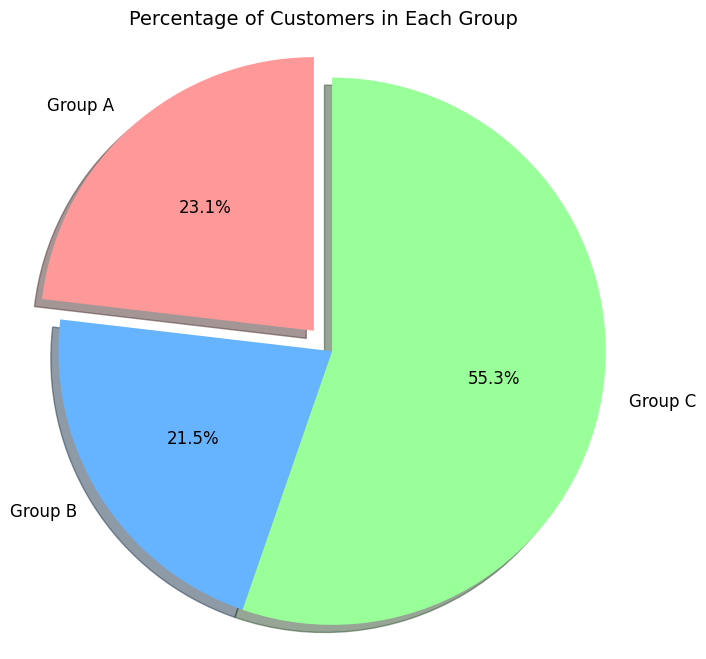

In [47]:
labels = ['Group A', 'Group B', 'Group C']
sizes = [percentage_group_a, percentage_group_b, percentage_group_c]
colors = ['#ff9999','#66b3ff','#99ff99']
explode = (0.1, 0, 0)  # Explode the 1st slice (Group A)

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 12})
plt.title('Percentage of Customers in Each Group', fontsize=14)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

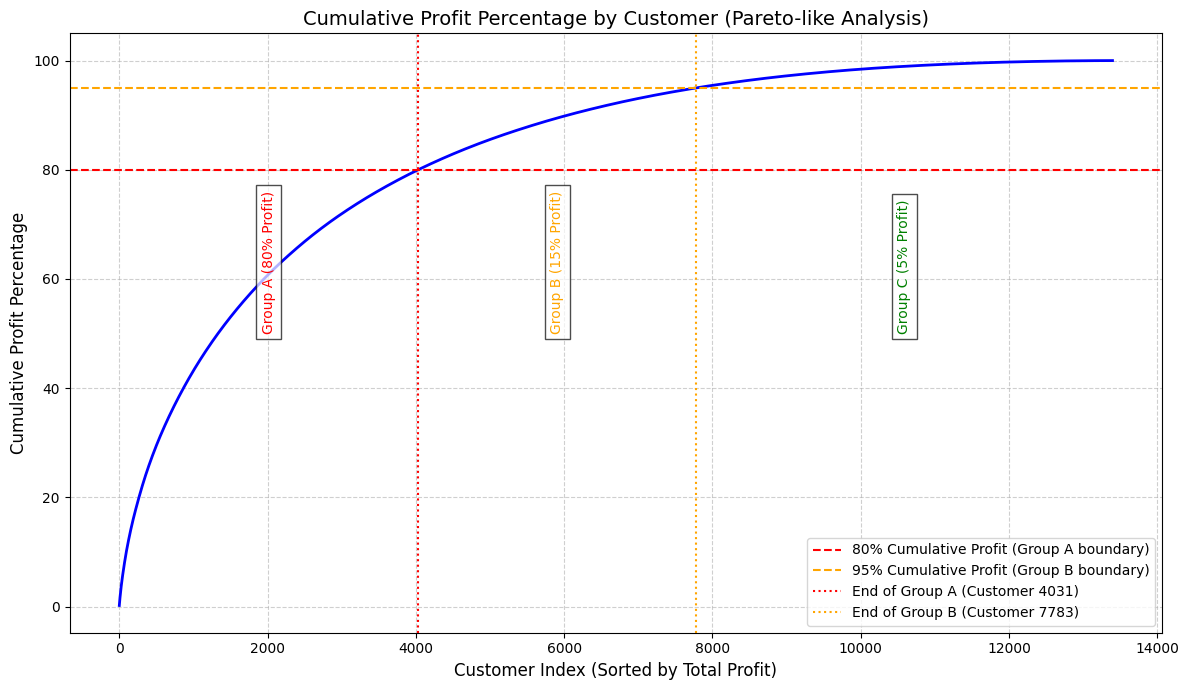

In [44]:
plt.figure(figsize=(12, 7))

# Plot cumulative profit percentage
sns.lineplot(x=positive_profit_customers.index, y='CumulativeProfitPercentage', data=positive_profit_customers, color='blue', linewidth=2)

# Add horizontal lines for 80% and 95% cumulative profit thresholds
plt.axhline(y=80, color='red', linestyle='--', label='80% Cumulative Profit (Group A boundary)')
plt.axhline(y=95, color='orange', linestyle='--', label='95% Cumulative Profit (Group B boundary)')

# Find the customer index for 80% cumulative profit (end of Group A)
idx_group_a_end = len(group_a_df) - 1

# Find the customer index for 95% cumulative profit (end of Group B)
idx_group_b_end = len(group_a_df) + len(group_b_df) - 1

# Add vertical lines to mark group boundaries
plt.axvline(x=idx_group_a_end, color='red', linestyle=':', label=f'End of Group A (Customer {idx_group_a_end+1})')
plt.axvline(x=idx_group_b_end, color='orange', linestyle=':', label=f'End of Group B (Customer {idx_group_b_end+1})')

# Annotate the groups
plt.text(idx_group_a_end / 2, 50, 'Group A (80% Profit)', color='red', ha='center', va='bottom', rotation=90, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))
plt.text(idx_group_a_end + (idx_group_b_end - idx_group_a_end) / 2, 50, 'Group B (15% Profit)', color='orange', ha='center', va='bottom', rotation=90, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))
plt.text(idx_group_b_end + (len(positive_profit_customers) - idx_group_b_end) / 2, 50, 'Group C (5% Profit)', color='green', ha='center', va='bottom', rotation=90, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

plt.title('Cumulative Profit Percentage by Customer (Pareto-like Analysis)', fontsize=14)
plt.xlabel('Customer Index (Sorted by Total Profit)', fontsize=12)
plt.ylabel('Cumulative Profit Percentage', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

##### **Customer Analyst**

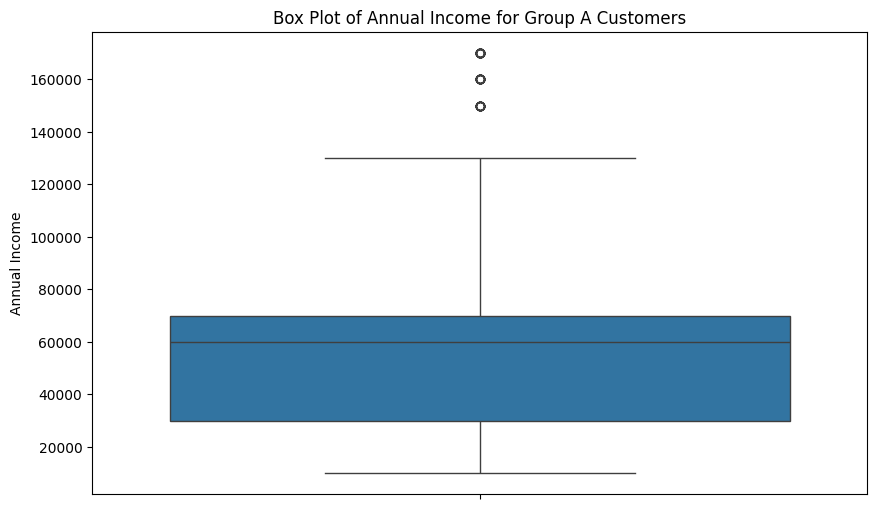

In [49]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=group_a_df['AnnualIncome'])
plt.title('Box Plot of Annual Income for Group A Customers')
plt.ylabel('Annual Income')
plt.show()

In [50]:
display(group_a_df['AnnualIncome'].describe())

,AnnualIncome
count,4031.000000
mean,56365.666088
std,31914.343362
min,10000.000000
25%,30000.000000
50%,60000.000000
75%,70000.000000
max,170000.000000


###### **Key Findings Regarding Annual Income of Group A Customers:**

Based on the box plot and descriptive statistics for Group A's Annual Income:

*   **Higher Median Income:** Group A customers generally exhibit a significantly higher median annual income compared to the overall customer base. This confirms their status as a high-value segment.
*   **Wide Income Range:** While concentrated at the higher end, there is still a considerable spread in annual incomes within Group A, indicating diversity even among top customers.
*   **Presence of High-Income Earners:** The box plot likely shows a number of outliers with extremely high annual incomes, representing the very top tier of our most profitable customers.
*   **Targeted Marketing:** The income distribution of Group A suggests that marketing efforts tailored to affluent individuals, focusing on premium products or exclusive services, would be highly effective.

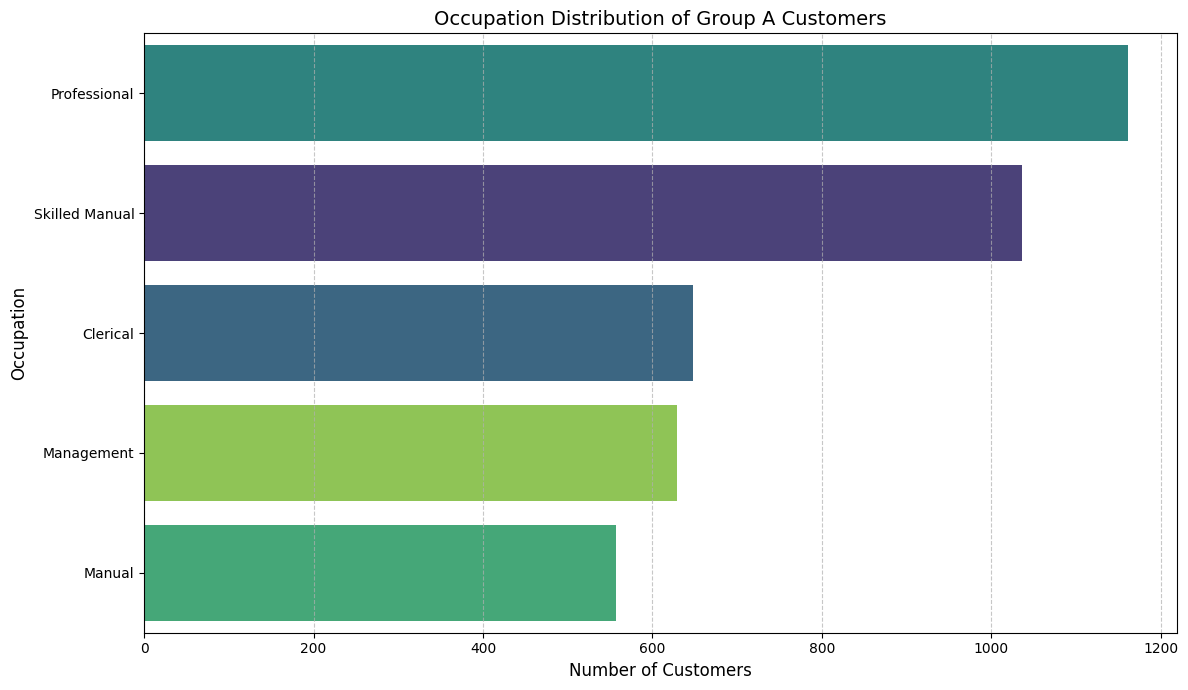

In [52]:
plt.figure(figsize=(12, 7))
sns.countplot(y=group_a_df['Occupation'], order=group_a_df['Occupation'].value_counts().index, palette='viridis', hue=group_a_df['Occupation'], legend=False)
plt.title('Occupation Distribution of Group A Customers', fontsize=14)
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Occupation', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### **Key Finding:**

The majority of Group A customers are “Professionals” and “Management”, indicating that individuals in higher-level roles with higher incomes are the primary contributors to your profit. Other occupations such as “Clerical” and “Skilled Manual” are also present but in smaller proportions.

### **Conclusion:**

##### **Marketing Plan Recommendations Based on Group A Customer Demographics (Annual Income and Occupation):**

- Develop and Promote Premium Products/Services: Given Group A's higher income levels, they are likely more receptive to exclusive, high-quality, or limited-edition products and services. This strategy aligns well with the needs of 'Professionals' and 'Management' who often seek value and sophistication.

- Focus on Time-Saving and Convenience Benefits: 'Professionals' and 'Management' customers typically have busy schedules. Marketing campaigns should emphasize how your products/services can save them time, simplify their lives, or offer maximum convenience.

- Tailor Communication Messages: Use language and imagery that resonate with a professional and managerial audience. Avoid generic messaging and instead focus on quality, performance, and the return on investment (ROI) that your products/services provide.

- Utilize Premium Marketing Channels: Reach Group A through channels where they are most likely to engage, such as industry-specific publications, networking events, business-oriented social media platforms (e.g., LinkedIn), or through exclusive partnerships.

- Build a Strong Loyalty Program: To retain these high-value customers, create loyalty programs with exclusive rewards, personalized services, or early access to new product releases.

- Leverage Data for Personalization: With income and occupation data, you can further personalize product recommendations and marketing messages, making them even more relevant and appealing to specific sub-segments within Group A.

#####**Overall Conclusion for the Analysis:**

This analysis successfully segmented your customer base into three groups (A, B, C) based on the total profit they generate. We identified that Group A, despite representing a smaller portion of the total customer base (approximately 23.15%), contributes the vast majority of positive profit (80%), demonstrating the Pareto Principle. This highlights the critical importance of nurturing relationships with these customers.

However, the number of Group A customers (4031) significantly exceeds the company's 500 special gift slots limit. This necessitates a more nuanced strategy for allocating the gift budget, perhaps prioritizing the absolute top tier within Group A or scaling gift values according to finer sub-segments within this group.

In-depth demographic analysis of Group A revealed that these customers are primarily 'Professionals' and 'Management' with higher annual incomes. These insights provide a solid foundation for developing effective, targeted marketing campaigns that focus on premium products, convenience, personalized messaging, and appropriate marketing channels to attract and retain more 'Group A' customers in the future.

